In [1]:
import math
import random

import torch
import torchvision.models as models
import numpy as np

In [2]:
model = models.mobilenet_v3_small(pretrained=True)
model.classifier = torch.nn.Identity()
model.to('cuda')
model.eval()
print(model)
print(next(model.parameters()).device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

/home/vitya/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vitya/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
fake_image = torch.randn(1, 3, 480, 640)

with torch.no_grad():
    predict = model(fake_image)

In [12]:
predict.shape

torch.Size([1, 576])

In [18]:
fake_image = np.random.rand(480, 640, 3)
fake_image_tensor = torch.from_numpy(fake_image).permute(2, 0, 1).unsqueeze(0).float()
fake_image_tensor.shape, fake_image_tensor.dtype

(torch.Size([1, 3, 480, 640]), torch.float32)

In [21]:
with torch.no_grad():
    emb = model(fake_image_tensor).squeeze(0).numpy()
    print(emb.shape, emb.dtype)
    

(576,) float32


In [3]:
arm_pose = np.array([0.956514, 0.126503, 0.407556])
cube_pose = np.array([1.5, 0, 0])

dist = np.linalg.norm(cube_pose - arm_pose)
print(dist)

0.6910006760785404


In [8]:
for i in range(10):
        angle = math.radians(random.uniform(-45, 45))
        radius = 1.5
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        z = 0.05
        print(x, y, z)
        print(np.linalg.norm(np.array([x, y, z])))

1.2923806360334844 0.7614146646904604 0.05
1.5008331019803633
1.488360379924451 -0.18650302804819024 0.05
1.5008331019803633
1.492674486524543 0.1480637608555604 0.05
1.5008331019803638
1.4925484892028993 0.14932852164989385 0.05
1.5008331019803633
1.3570022289963517 0.6391752111111111 0.05
1.5008331019803636
1.4420805104832766 0.41279995310597195 0.05
1.5008331019803633
1.3609459151599492 0.6307346637132355 0.05
1.5008331019803633
1.1407760400762352 0.973976399297223 0.05
1.5008331019803633
1.418180427971893 -0.4886351130623523 0.05
1.5008331019803633
1.4908107767568437 0.16578066203769393 0.05
1.5008331019803633


In [5]:
np.linalg.norm(np.array([0.970728, -0.565225, 0.049995]))

1.1244072441219863

In [ ]:



# angle = random.uniform(-90 / 2, 90 / 2)
angle = math.radians(45)
radius = 1.5
x = radius * math.cos(angle)
y = radius * math.sin(angle)
z = 0.05

x, y, z

(1.0606601717798214, 1.0606601717798212, 0.05)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import os

def live_plot_training_progress(csv_file, update_interval=3):
    """
    Динамически обновляемые графики обучения в Jupyter Notebook
    с фиксированным размером и читаемыми осями
    """
    # Инициализация фигуры и осей один раз
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(20, 15))
    plt.close(fig)  # Закрываем, чтобы не дублировать вывод
    
    try:
        while True:
            # Проверка и чтение данных (как в предыдущем коде)
            if not os.path.exists(csv_file):
                print(f"Ожидание файла {csv_file}...")
                time.sleep(update_interval)
                continue
                
            try:
                df = pd.read_csv(csv_file)
                if df.empty:
                    time.sleep(update_interval)
                    continue
            except Exception as e:
                print(f"Ошибка чтения файла: {e}")
                time.sleep(update_interval)
                continue
                
            clear_output(wait=True)
            
            # Очистка осей
            for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
                ax.clear()
            
            # 1. График наград
            ax1.plot(df['episode'], df['episode_reward'], 'b-')
            ax1.set_title(f'Награда за эпизод (последняя: {df["episode_reward"].iloc[-1]:.2f})')
            ax1.set_ylabel('Награда')
            ax1.grid(True)
            ax1.tick_params(axis='x', labelrotation=45)  # Наклон подписей
            
            # 2. Средняя награда
            ax2.plot(df['episode'], df['mean_reward_100'], 'r-')
            ax2.set_title(f'Средняя награда (100 эп.)\nПоследняя: {df["mean_reward_100"].iloc[-1]:.2f}')
            ax2.set_ylabel('Награда')
            ax2.grid(True)
            ax2.tick_params(axis='x', labelrotation=45)
            
            # 3. Длина эпизода
            ax3.plot(df['episode'], df['episode_length'], 'g-', label=f'Длина\nПоследняя: {df["episode_length"].iloc[-1]}')
            ax3.plot(df['episode'], df['mean_length_100'], 'orange', label=f'Средняя (100)\nПоследняя: {df["mean_length_100"].iloc[-1]:.2f}')
            ax3.set_title('Длина эпизодов')
            ax3.set_ylabel('Шаги')
            ax3.legend()
            ax3.grid(True)
            ax3.tick_params(axis='x', labelrotation=45)
            
            # 4. Лосс актора
            ax4.plot(df['episode'], df['actor_loss'], 'm-')
            ax4.set_title(f'Лосс актора\nПоследний: {df["actor_loss"].iloc[-1]:.4f}')
            ax4.set_ylabel('Лосс')
            ax4.grid(True)
            ax4.tick_params(axis='x', labelrotation=45)
            
            # 5. Лосс критика
            ax5.plot(df['episode'], df['critic_loss'], 'c-')
            ax5.set_title(f'Лосс критика\nПоследний: {df["critic_loss"].iloc[-1]:.4f}')
            ax5.set_ylabel('Лосс')
            ax5.grid(True)
            ax5.tick_params(axis='x', labelrotation=45)
            
            # 6. Learning rate
            if 'learning_rate' in df.columns:
                ax6.plot(df['episode'], df['learning_rate'], 'y-')
                ax6.set_title(f'Learning Rate\nПоследний: {df["learning_rate"].iloc[-1]:.6f}')
                ax6.set_ylabel('LR')
                ax6.grid(True)
                ax6.tick_params(axis='x', labelrotation=45)
            else:
                ax6.axis('off')  # Скрываем если данных нет
            
            fig.tight_layout(pad=3.0)  # Увеличиваем отступы
            display(fig)
            
            time.sleep(update_interval)
            
    except KeyboardInterrupt:
        plt.close('all')
        print("Визуализация остановлена")
    except Exception as e:
        plt.close('all')
        print(f"Произошла ошибка: {e}")

/home/vitya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


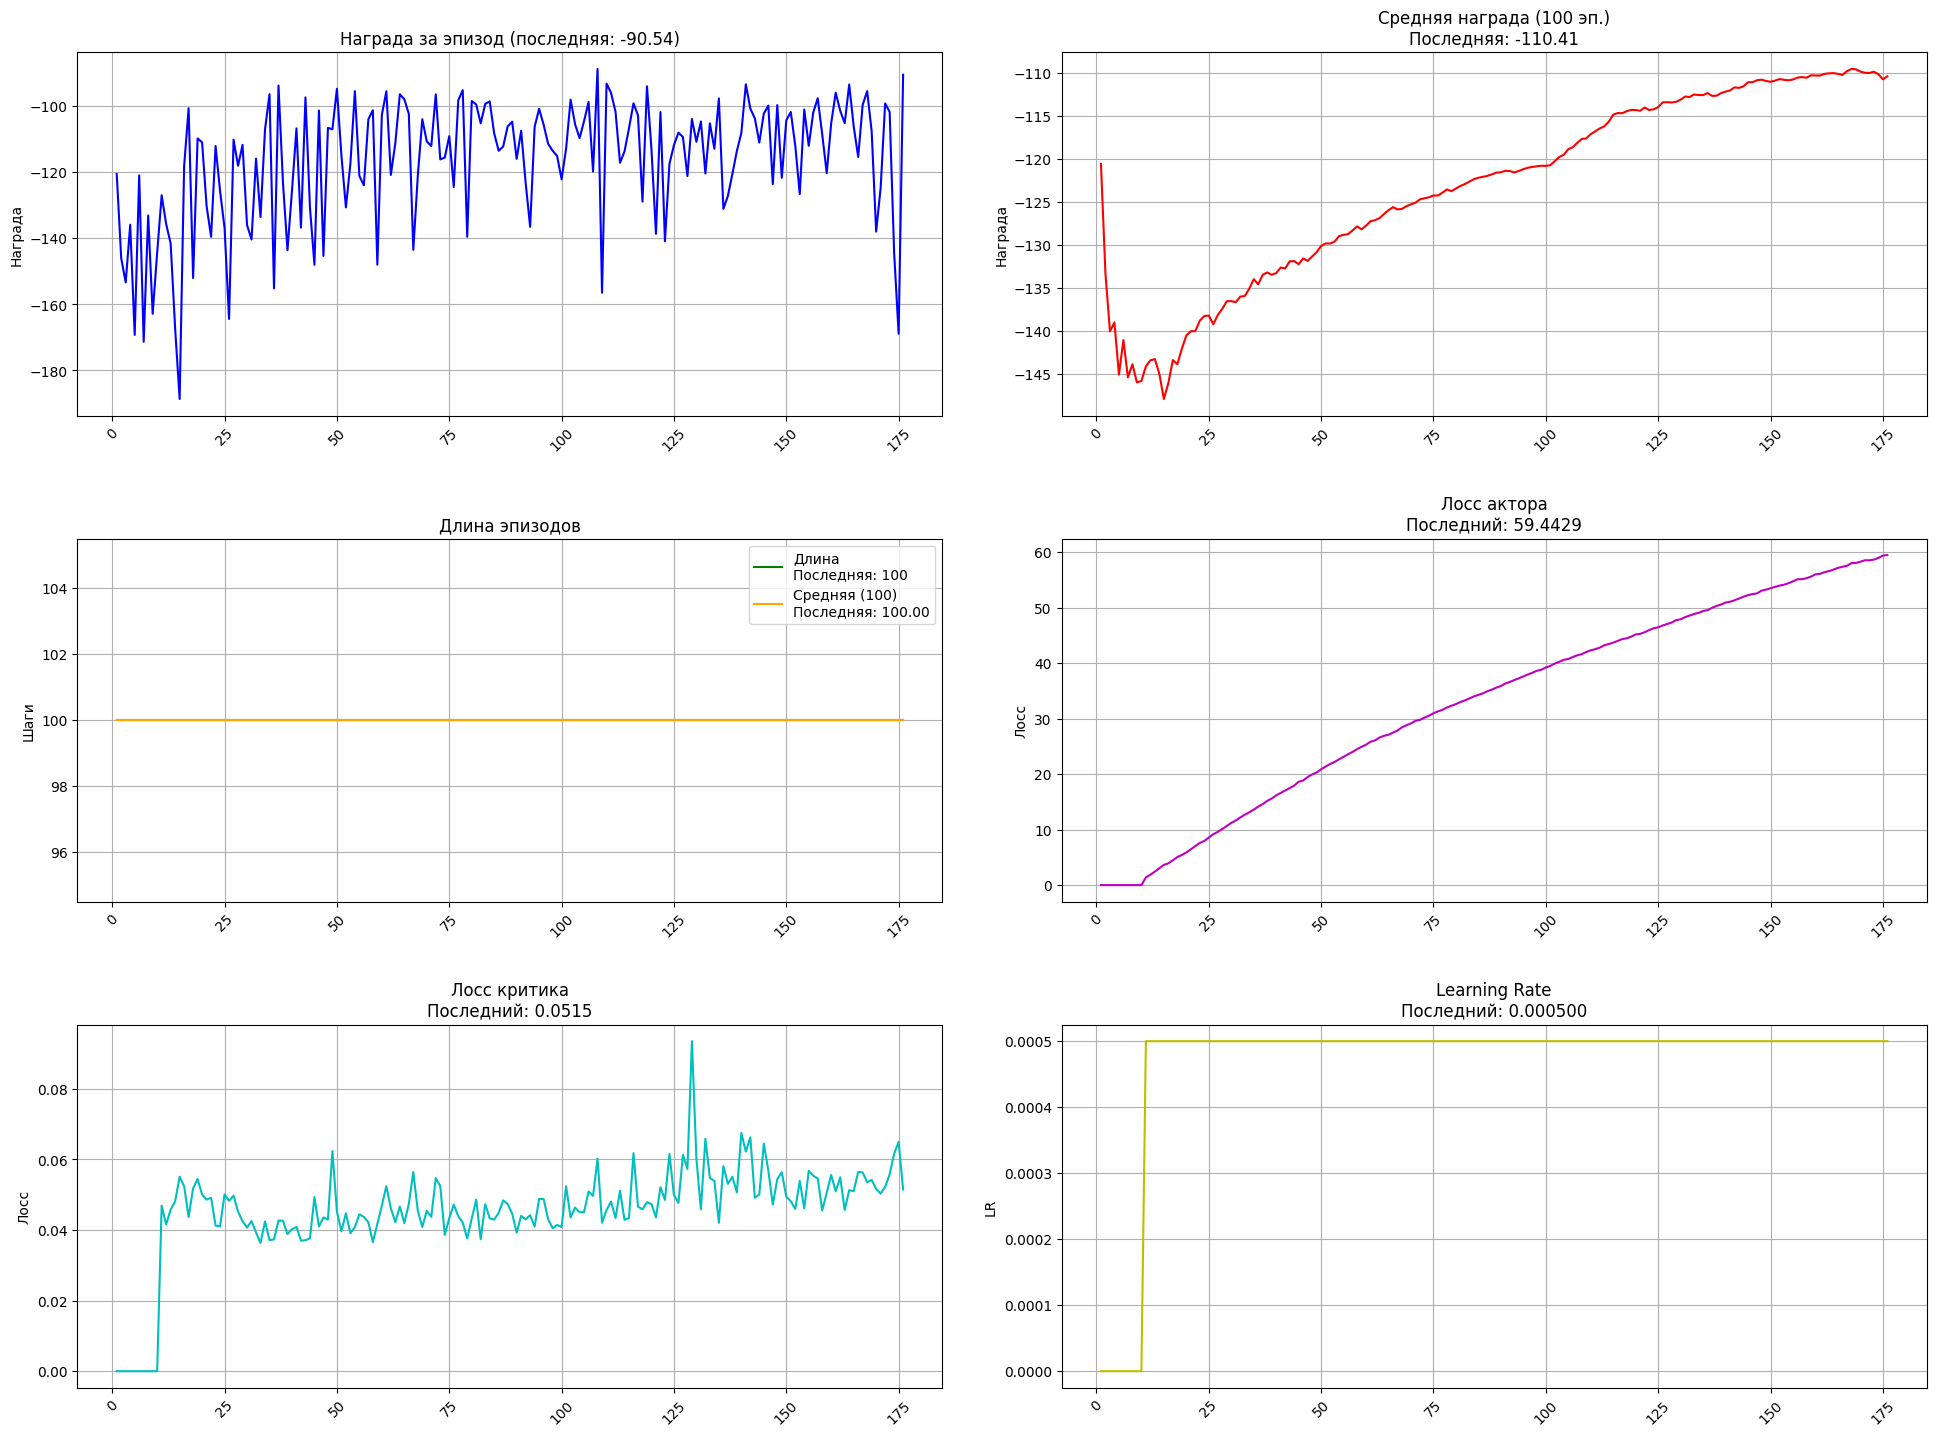

Визуализация остановлена


In [4]:
live_plot_training_progress('/home/vitya/diploma/roboarm/src/roboarm_rl/training_logs/20250521/training_log_20250522_032656.csv')

In [21]:
np.linalg.norm(np.array([0.890791, -0.315372, 0.366259] - np.array([1.38, -0.6, 0.05])))

0.6483504447025543

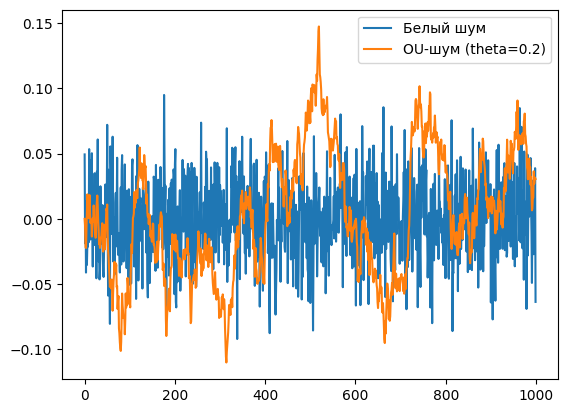

In [95]:
import numpy as np
import matplotlib.pyplot as plt

def ou_noise(theta, sigma, dt, n_steps):
    noise = np.zeros(n_steps)
    for t in range(1, n_steps):
        noise[t] = noise[t-1] + theta * (0 - noise[t-1]) * dt + sigma * np.random.normal(0, np.sqrt(dt))
    return noise

white_noise = np.random.normal(0, 0.03, 1000)
ou = ou_noise(theta=0.1, sigma=0.03, dt=0.1, n_steps=1000)

plt.plot(white_noise, label='Белый шум')
plt.plot(ou, label='OU-шум (theta=0.2)')
plt.legend()
plt.show()

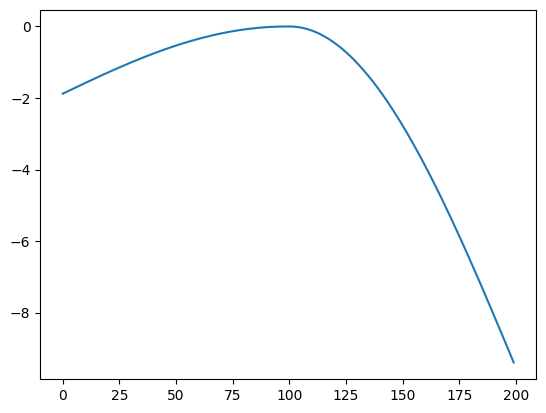

In [115]:
ar = np.concatenate([np.linspace(1.51, 0, 100), -np.linspace(0, 1.51, 100)])
mask = ar < 0
multiplier = np.where(mask, np.full(shape=ar.shape, fill_value=-10), np.full(shape=ar.shape, fill_value=-2))

plt.plot(multiplier * (1 - np.cos(ar)))
# plt.plot(np.exp(-10 * np.cos(np.linspace(0, 0.75, 100))))
# plt.plot(-10 * (1 - np.cos(-np.linspace(0, 0.75, 100))))

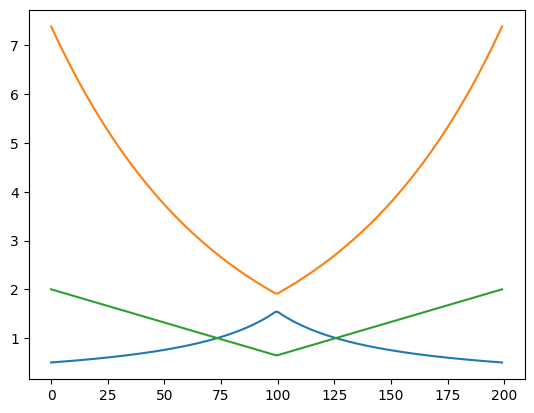

In [72]:
r = np.exp(np.linspace(0.65, 2.0, 100)**2)
r = 1 / np.concatenate([np.linspace(2.0, 0.65, 100), np.linspace(0.65, 2.0, 100)])
r1 = np.exp(np.concatenate([np.linspace(2.0, 0.65, 100), np.linspace(0.65, 2.0, 100)]))
r2 = np.concatenate([np.linspace(2.0, 0.65, 100), np.linspace(0.65, 2.0, 100)])
plt.plot(r)
plt.plot(r1)
plt.plot(r2)

In [62]:
import cv2
import random

img_path = '/home/vitya/diploma/roboarm_top_imgs/images_top/'
img_file = random.choice(os.listdir(img_path))


img = cv2.imread(img_path + img_file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
nimg = img / 255.0

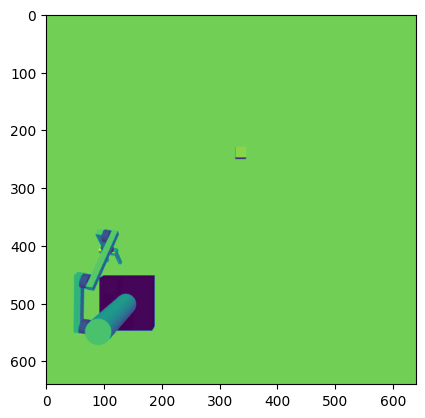

In [63]:
plt.imshow(img)

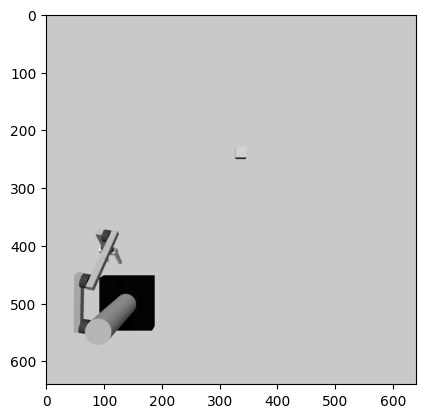

In [65]:
plt.imshow(nimg, cmap='gray')

In [28]:
entity_position = np.array([1.38, -0.60, 0.05])
entity_to_origin = np.linalg.norm(np.array(entity_position))
angle_entity = abs(np.arccos(np.dot(
    entity_position / entity_to_origin,
    # self._last_palm_pos['position'] / palm_to_origin
    np.array([1.0, 0.0, 0.0])
)))
print(angle_entity)

0.4113940971636752


In [30]:
angle_entity2 = np.arccos(
    entity_position[0] / np.linalg.norm(entity_position[:2])
)
print(angle_entity2)

0.41012734054149097


In [31]:
np.rad2deg(angle_entity), np.rad2deg(angle_entity2)

(23.5711454840735, 23.498565675952097)

In [9]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tqdm import tqdm
from torchvision import transforms
from PIL import Image

In [15]:
imgs_f = os.listdir('/home/vitya/diploma/roboarm_top_imgs2')
rwrds_f = os.listdir('/home/vitya/diploma/roboarm_top_rwrds2')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

_model = models.mobilenet_v3_small(weights=None)  # Не загружаем imagenet веса
_model.classifier = torch.nn.Identity()  # Удаляем классификатор
checkpoint = torch.load('/home/vitya/diploma/roboarm/src/roboarm_rl/roboarm_rl/notebooks/checkpoint_16.pth')
_model.load_state_dict(checkpoint)
_model.to('cuda')

transform = transforms.Compose([
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/home/vitya/diploma/roboarm_top_imgs2/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    imarr = transform(Image.fromarray(imarr)).unsqueeze(0)
    # print(imarr.size())
    with torch.no_grad():
        emb = _model(imarr.to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/home/vitya/diploma/roboarm_top_rwrds2/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 26492/26492 [04:16<00:00, 103.25it/s]


In [16]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

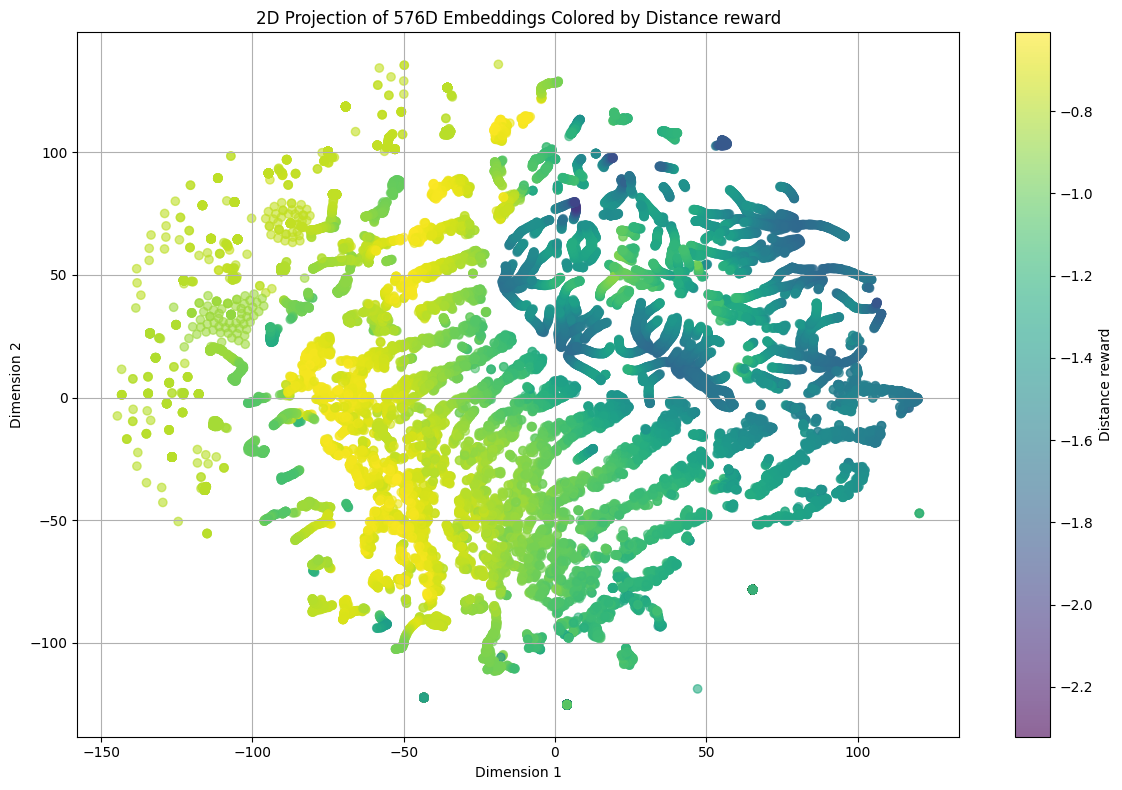

In [17]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

In [30]:
imgs_f = os.listdir('/home/vitya/diploma/roboarm_head_imgs')
rwrds_f = os.listdir('/home/vitya/diploma/roboarm_head_rwrds')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/home/vitya/diploma/roboarm_head_imgs/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        emb = model(torch.from_numpy(imarr).permute(2, 0, 1).unsqueeze(0).float().to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/home/vitya/diploma/roboarm_head_rwrds/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 64659/64659 [07:49<00:00, 137.79it/s]


In [31]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

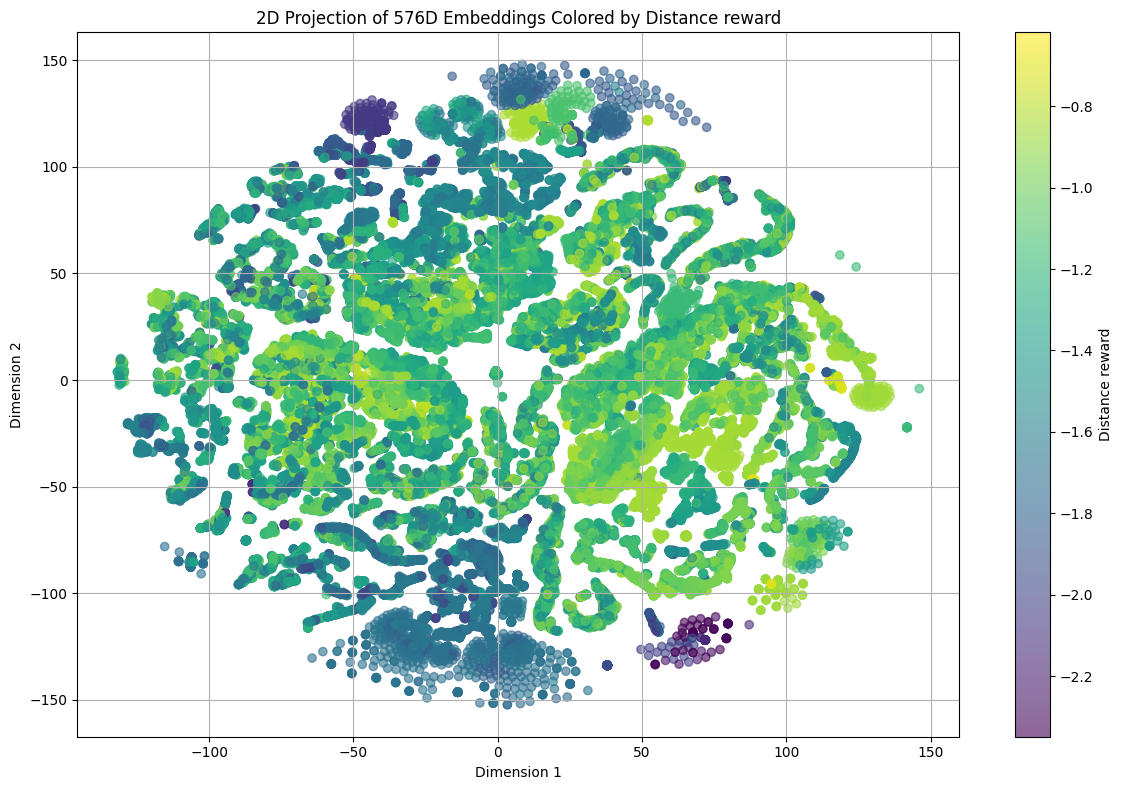

In [34]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

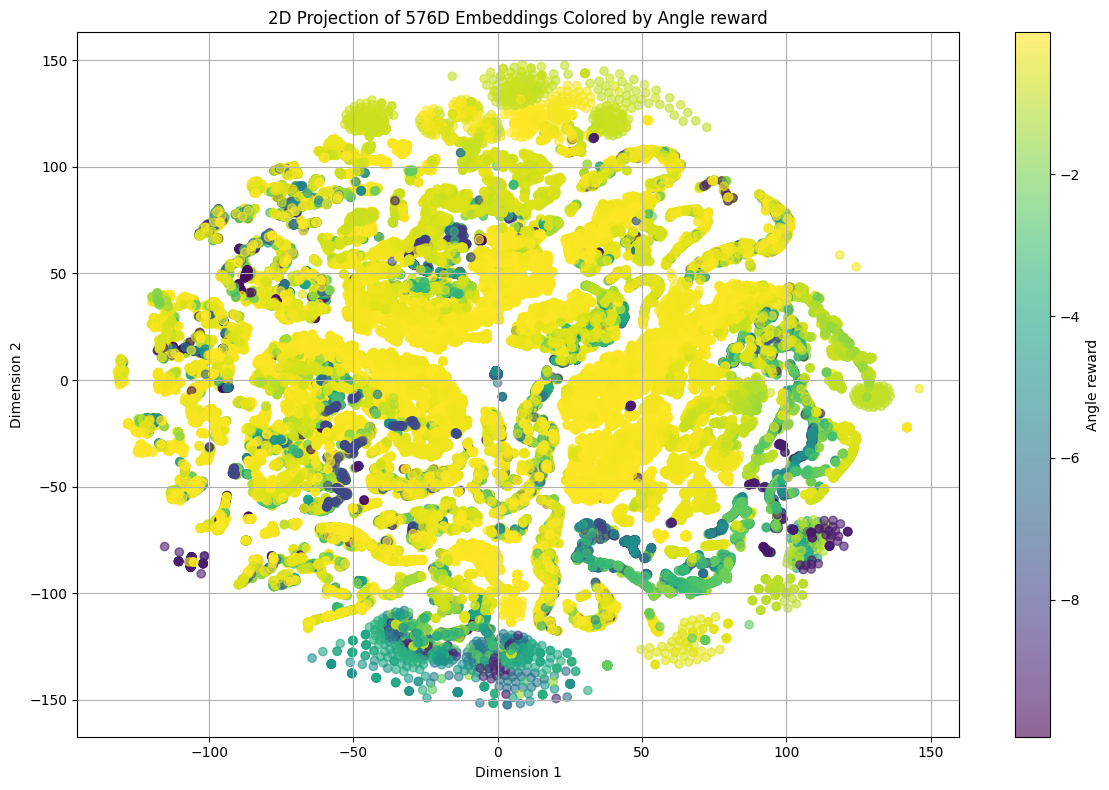

In [35]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 1],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Angle reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Angle reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

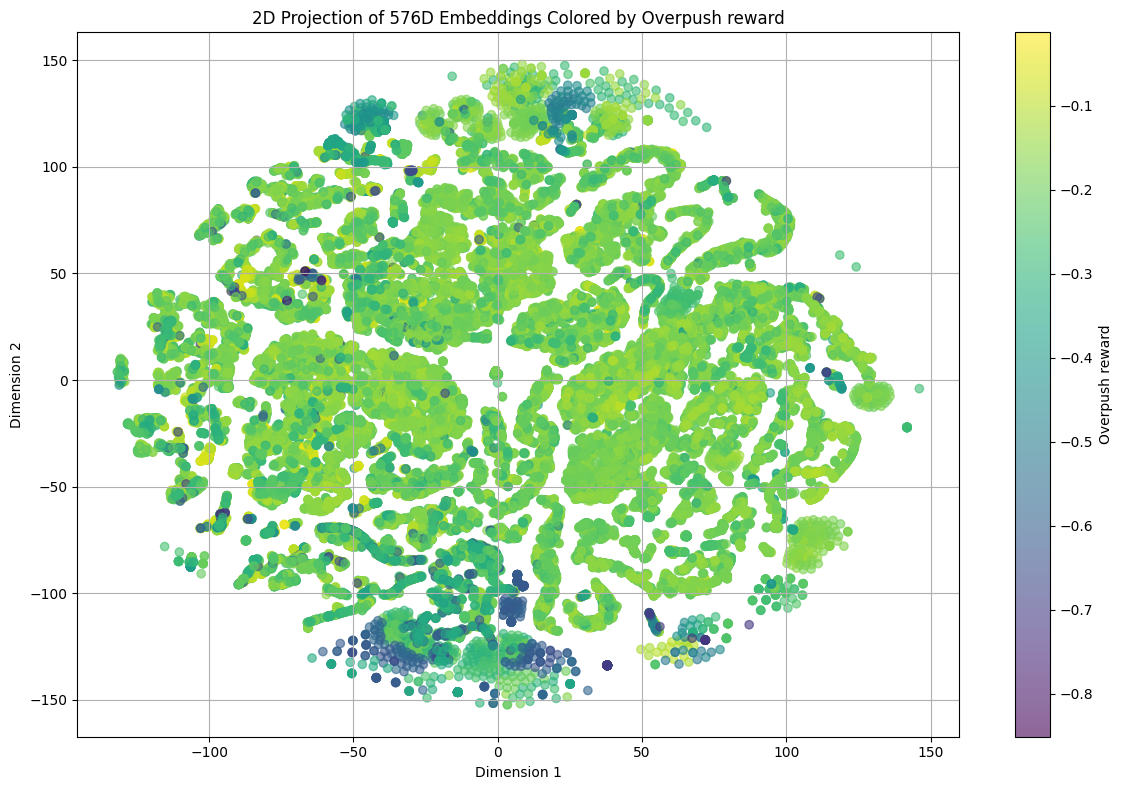

In [36]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 2],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Overpush reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Overpush reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

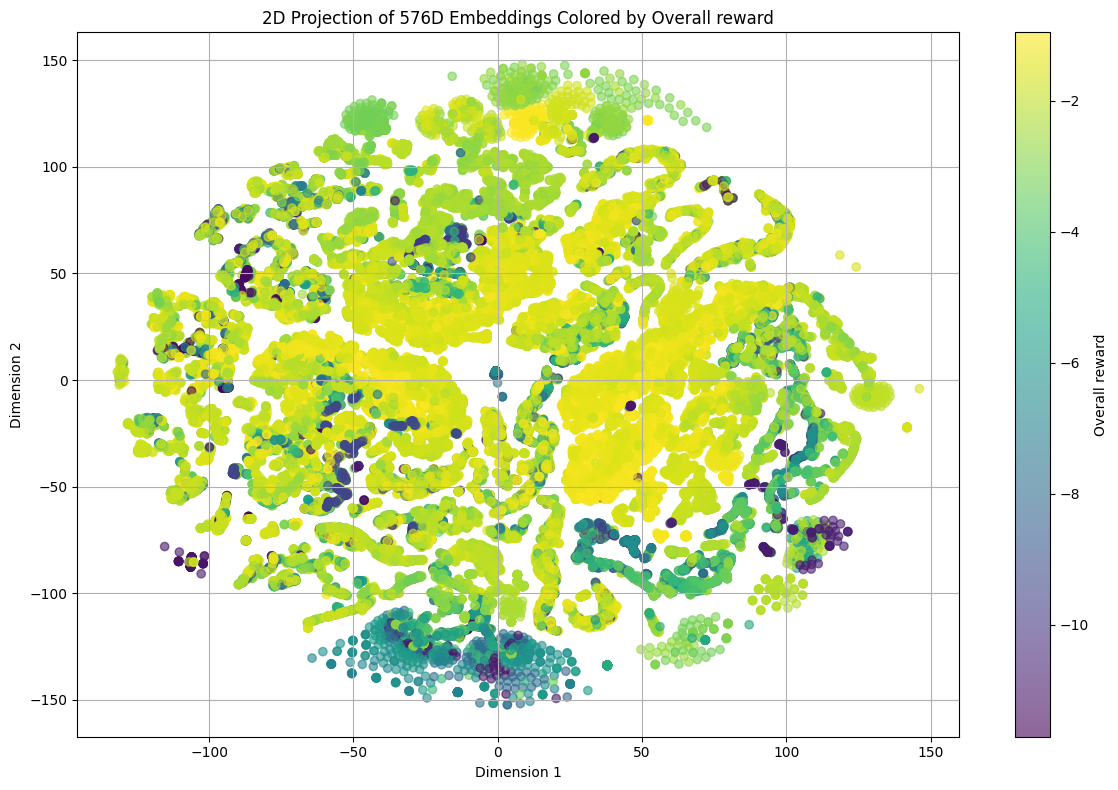

In [39]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=np.sum(rwrds, axis=1),
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Overall reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Overall reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

In [5]:
imgs_f = os.listdir('/home/vitya/diploma/roboarm_top_imgs/images_top')
rwrds_f = os.listdir('/home/vitya/diploma/roboarm_top_rwrds/rewards_top')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/home/vitya/diploma/roboarm_top_imgs/images_top/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        emb = model(torch.from_numpy(imarr).permute(2, 0, 1).unsqueeze(0).float().to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/home/vitya/diploma/roboarm_top_rwrds/rewards_top/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 44991/44991 [05:31<00:00, 135.52it/s]


In [6]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

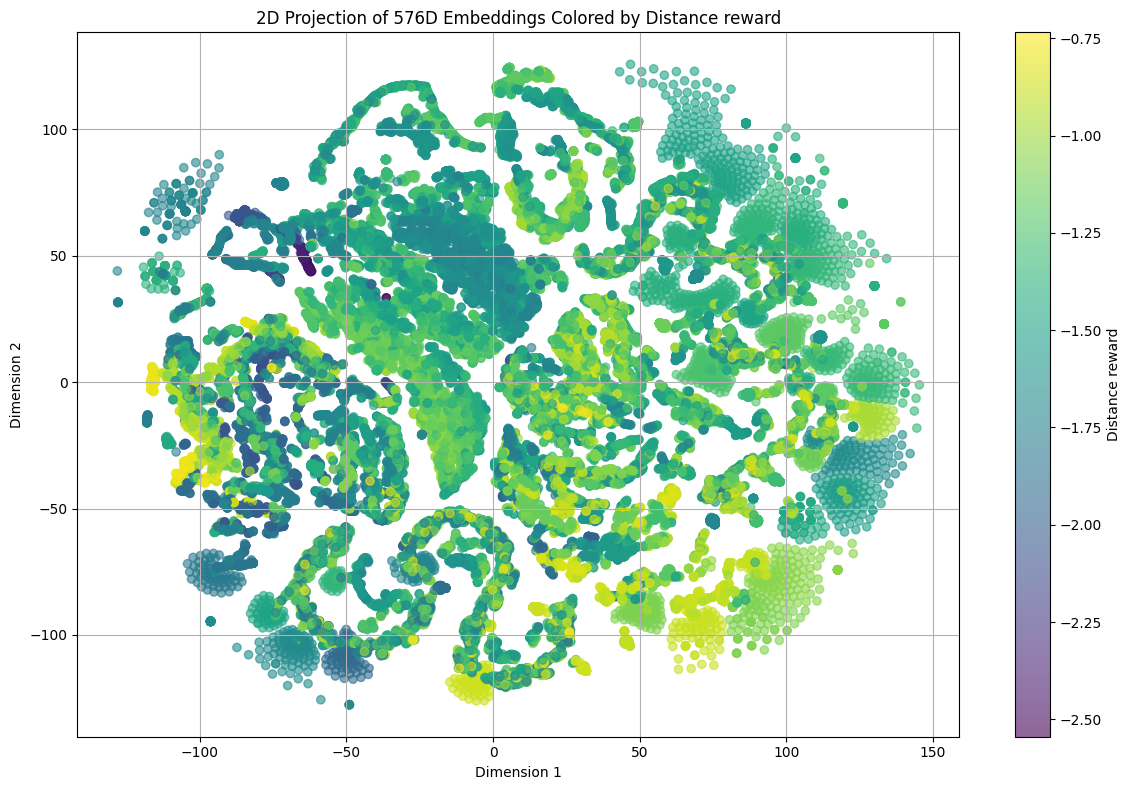

In [7]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

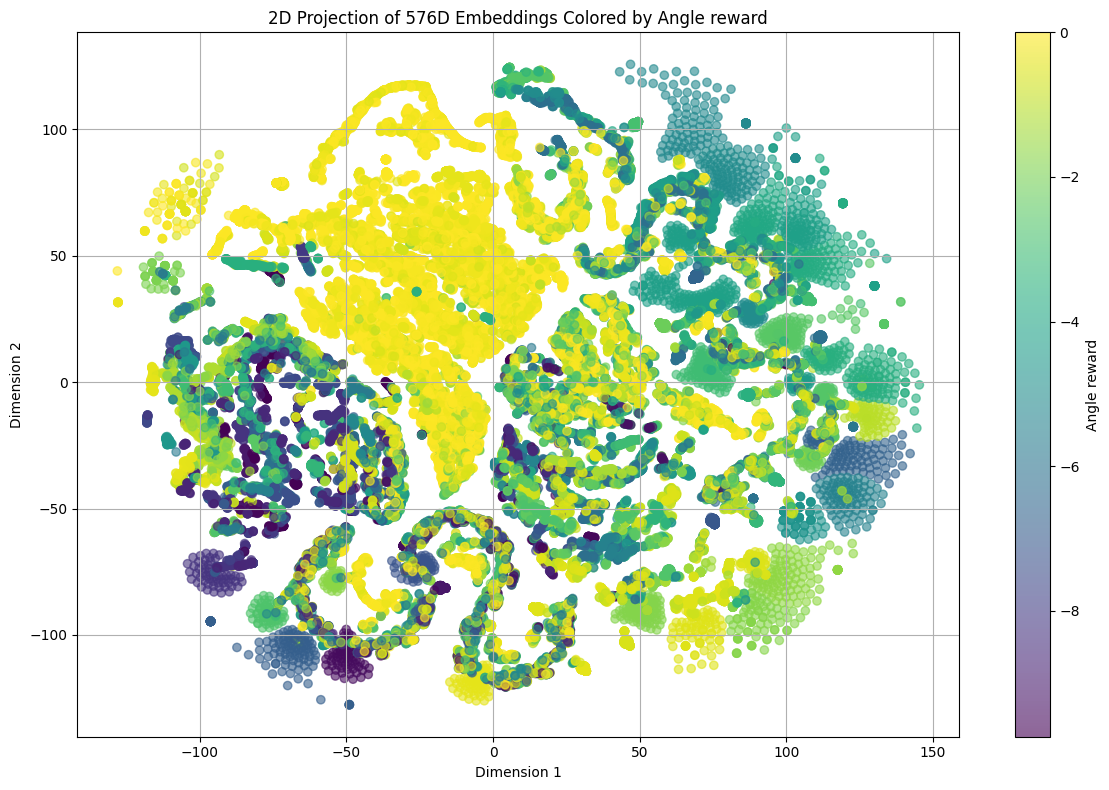

In [9]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 1],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Angle reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Angle reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

In [18]:
df = pd.read_csv('/home/vitya/diploma/roboarm/src/roboarm_rl/training_logs/20250521/training_log_20250521_014207.csv')

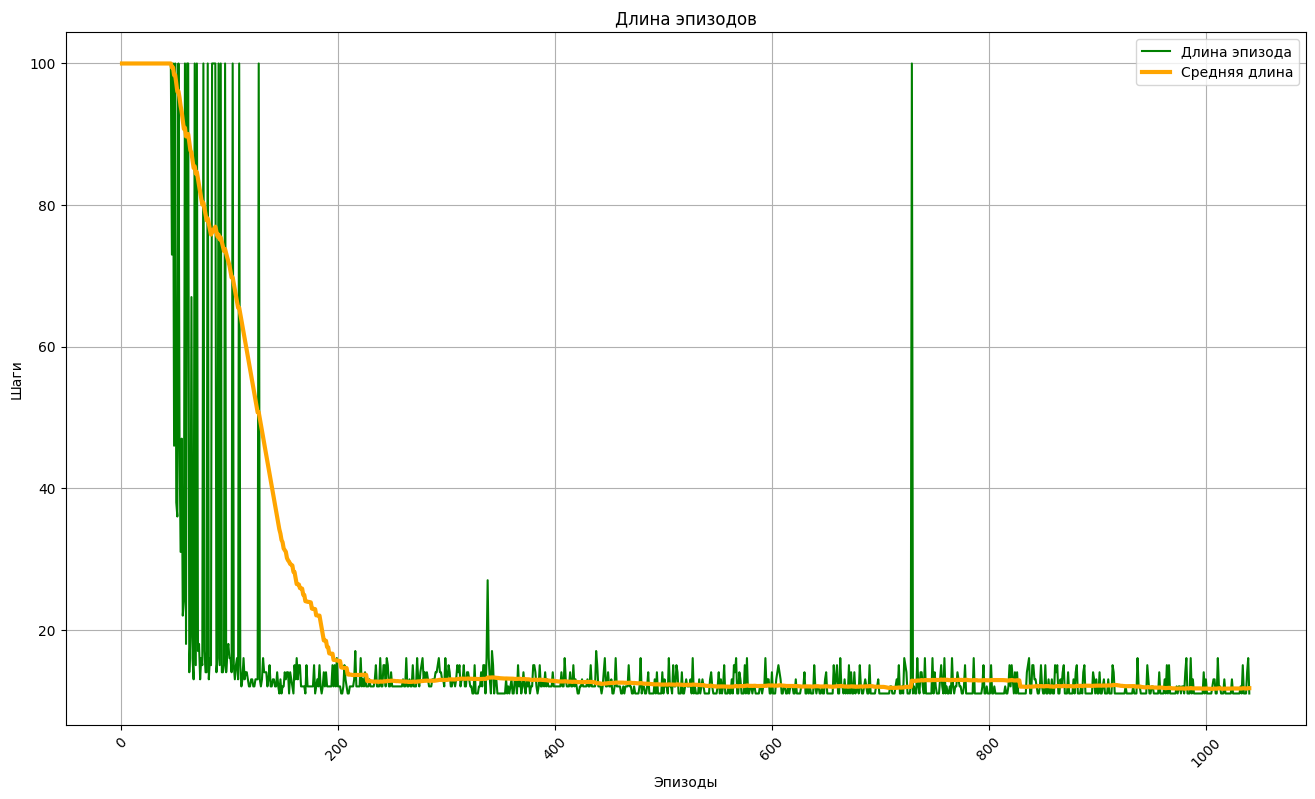

In [24]:
fig, ax3 = plt.subplots(figsize=(16, 9))

ax3.plot(df['episode'], df['episode_length'], 'g-', label=f'Длина эпизода')
ax3.plot(df['episode'], df['mean_length_100'], 'orange', lw=3, label=f'Средняя длина')
ax3.set_title('Длина эпизодов')
ax3.set_ylabel('Шаги')
ax3.set_xlabel('Эпизоды')
ax3.legend()
ax3.grid(True)
ax3.tick_params(axis='x', labelrotation=45)

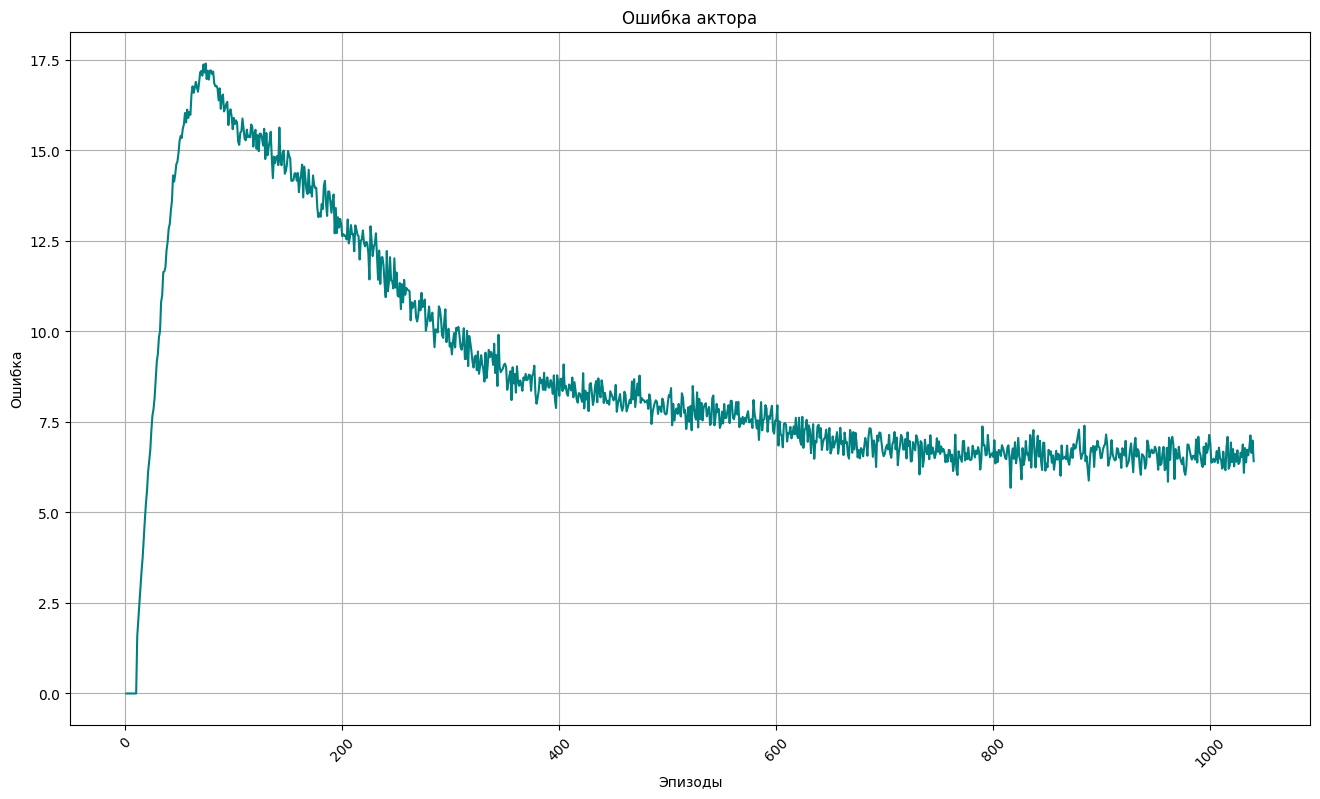

In [30]:
fig, ax3 = plt.subplots(figsize=(16, 9))

ax3.plot(df['episode'], df['actor_loss'], 'teal')
ax3.set_title('Ошибка актора')
ax3.set_ylabel('Ошибка')
ax3.set_xlabel('Эпизоды')
ax3.grid(True)
ax3.tick_params(axis='x', labelrotation=45)

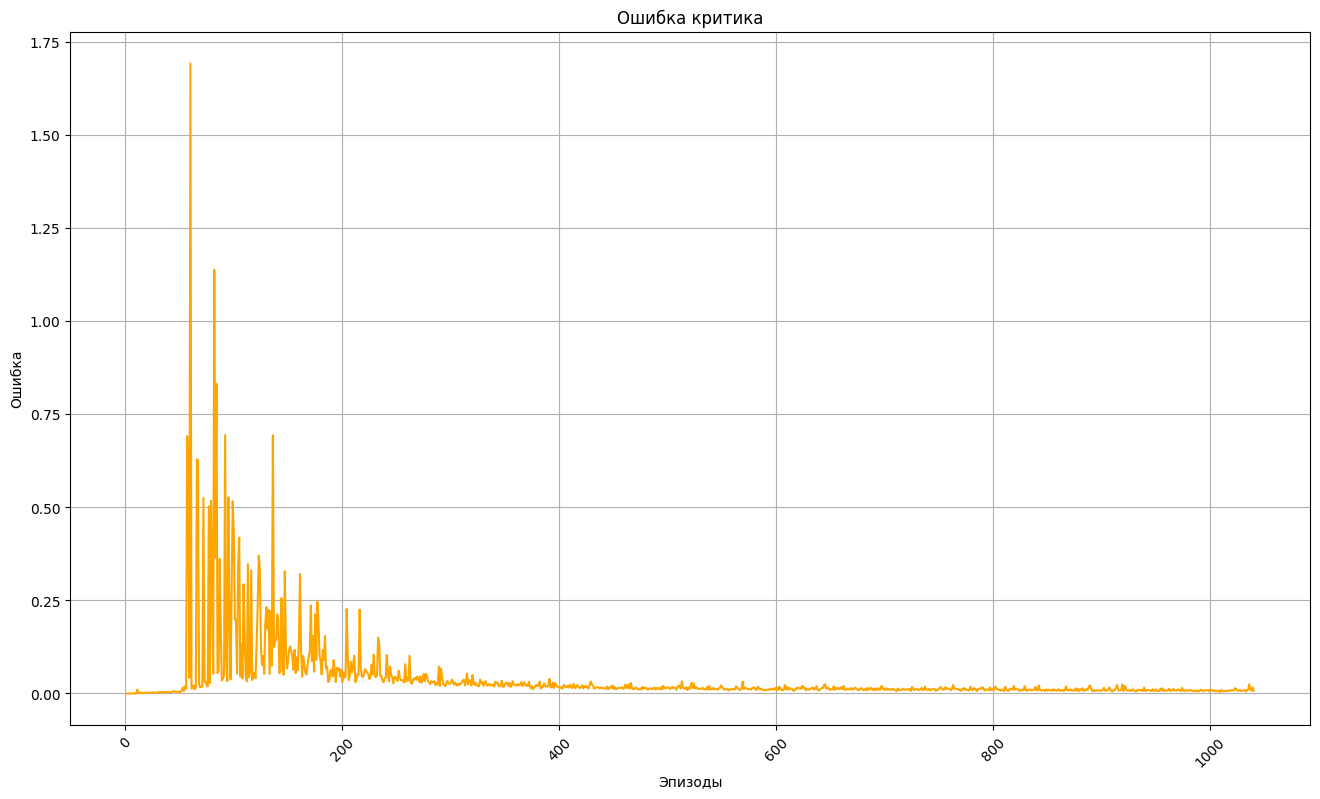

In [32]:
fig, ax3 = plt.subplots(figsize=(16, 9))

ax3.plot(df['episode'], df['critic_loss'], 'orange')
ax3.set_title('Ошибка критика')
ax3.set_ylabel('Ошибка')
ax3.set_xlabel('Эпизоды')
ax3.grid(True)
ax3.tick_params(axis='x', labelrotation=45)

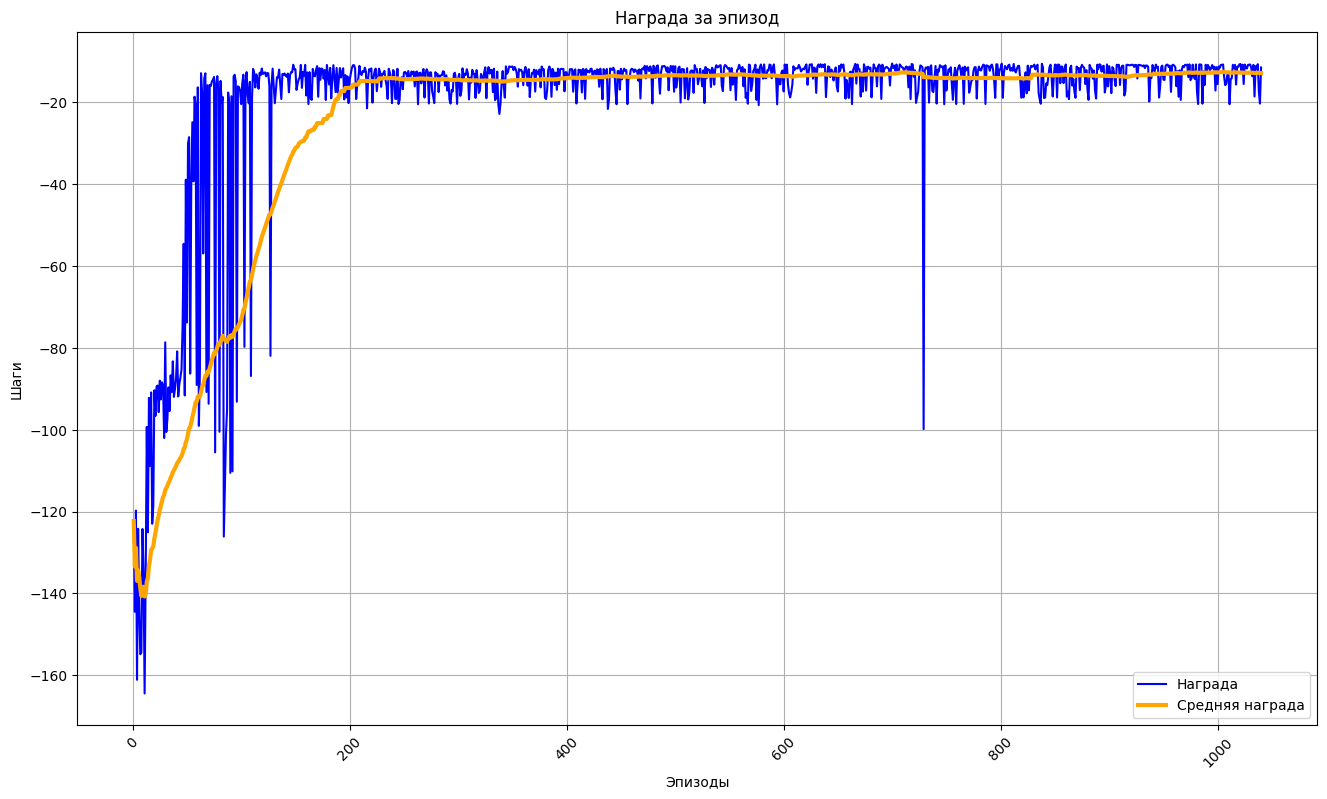

In [45]:
fig, ax3 = plt.subplots(figsize=(16, 9))

ax3.plot(df['episode'], df['episode_reward'], 'b-', label=f'Награда')
ax3.plot(df['episode'], df['mean_reward_100'], 'orange', lw=3, label=f'Средняя награда')
ax3.set_title('Награда за эпизод')
ax3.set_ylabel('Шаги')
ax3.set_xlabel('Эпизоды')
ax3.legend()
ax3.grid(True)
ax3.tick_params(axis='x', labelrotation=45)